# 02 – Modeling & Evaluation (Baseline)
**Projekt:** StepSense | ML4B SoSe 2026 | Gruppe: NoNames
**CRISP-DM Phasen:** Modeling + Evaluation

## Inhalt
1. Imports & Konfiguration
2. Daten laden
3. Baseline-Modell (Decision Tree)
4. Modellvergleich mit Cross-Validation
5. Bestes Modell – finale Evaluation
6. Konfusionsmatrix & Per-Klasse Metriken
7. Feature Importance
8. Modell exportieren
9. Mixed-Evaluation
10. Zusammenfassung & Bias-Diskussion


## 1. Imports & Konfiguration

In [156]:
import os
import json
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)

warnings.filterwarnings("ignore")

PROCESSED_PATH = "../data/processed"
MIXED_PATH     = "../data/mixed"
RANDOM_STATE   = 42

# Muss mit Notebook 01 uebereinstimmen
SENSOR_PREFIX = {
    "Accelerometer": "acc",
    "Gyroscope":     "gyro",
    "Orientation":   "orie",
}
SENSOR_COLUMNS = {
    "Accelerometer": ["x", "y", "z"],
    "Gyroscope":     ["x", "y", "z"],
    "Orientation":   ["roll", "pitch", "yaw"],
}

print("Setup abgeschlossen.")

Setup abgeschlossen.


## 2. Daten laden

In [157]:
# Feature-Namen laden
with open(f"{PROCESSED_PATH}/feature_names.txt") as f:
    feature_cols = [line.strip() for line in f.readlines()]

# Scaler laden (nur fuer Referenz – wird in CV nicht direkt genutzt)
with open(f"{PROCESSED_PATH}/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

# Session-Split laden (benoetigt fuer GroupKFold in Cross-Validation)
with open(f"{PROCESSED_PATH}/session_split.json") as f:
    session_split = json.load(f)
train_sessions = session_split["train"]
val_sessions   = session_split["val"]
test_sessions  = session_split["test"]

# Alle unskalierten Features laden (CV skaliert intern je Fold)
df_all = pd.read_csv(f"{PROCESSED_PATH}/features_all.csv")

# Unskalierte Train+Val Daten fuer GroupKFold-CV
mask_tv = df_all["session"].isin(train_sessions + val_sessions)
X_trainval_raw  = df_all.loc[mask_tv, feature_cols].reset_index(drop=True)
y_trainval      = df_all.loc[mask_tv, "label"].reset_index(drop=True)
groups_trainval = df_all.loc[mask_tv, "session"].reset_index(drop=True)

# Unskalierte Test-Daten fuer finale Evaluation
mask_te    = df_all["session"].isin(test_sessions)
X_test_raw = df_all.loc[mask_te, feature_cols].reset_index(drop=True)
y_test     = df_all.loc[mask_te, "label"].reset_index(drop=True)

# Skalierte Splits (nur fuer Baseline Decision Tree in Abschnitt 3)
X_train = pd.read_csv(f"{PROCESSED_PATH}/X_train.csv")
X_val   = pd.read_csv(f"{PROCESSED_PATH}/X_val.csv")
y_train = pd.read_csv(f"{PROCESSED_PATH}/y_train.csv").squeeze()
y_val   = pd.read_csv(f"{PROCESSED_PATH}/y_val.csv").squeeze()

print(f"Train+Val (roh):  {len(X_trainval_raw):>5} Fenster x {X_trainval_raw.shape[1]} Features | {groups_trainval.nunique()} Sessions")
print(f"Test      (roh):  {len(X_test_raw):>5} Fenster")
print(f"\nKlassenverteilung Train+Val:")
print(y_trainval.value_counts().sort_index().to_string())

Train+Val (roh):   1571 Fenster x 72 Features | 22 Sessions
Test      (roh):    426 Fenster

Klassenverteilung Train+Val:
label
Gehen            529
Laufen           290
Liegen           376
Stehen           144
Treppe_hoch      125
Treppe_runter    107


## 3. Baseline-Modell – Decision Tree

Ein einfacher Decision Tree als Ausgangspunkt (Baseline).  
Kein Hyperparameter-Tuning — Standardeinstellungen mit `class_weight='balanced'` wegen Klassenungleichgewicht.


In [158]:
baseline = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=RANDOM_STATE
)
baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_val)
acc_baseline = accuracy_score(y_val, y_pred_baseline)
f1_baseline  = f1_score(y_val, y_pred_baseline, average="weighted")

print(f"=== Baseline: Decision Tree ===")
print(f"Accuracy (Val):          {acc_baseline:.4f}")
print(f"F1 gewichtet (Val):      {f1_baseline:.4f}")
print()
print(classification_report(y_val, y_pred_baseline, zero_division=0))


=== Baseline: Decision Tree ===
Accuracy (Val):          0.6088
F1 gewichtet (Val):      0.6483

               precision    recall  f1-score   support

        Gehen       0.99      0.63      0.77       120
       Laufen       0.80      0.95      0.87        98
       Liegen       0.92      0.20      0.32       117
       Stehen       0.00      0.00      0.00         0
  Treppe_hoch       0.59      0.97      0.74        40
Treppe_runter       0.67      0.53      0.59        34

     accuracy                           0.61       409
    macro avg       0.66      0.55      0.55       409
 weighted avg       0.86      0.61      0.65       409



## 4. Modellvergleich – Cross-Validation

5-fache Stratified Cross-Validation auf Train+Val.  
Metriken: gewichtetes F1 (Hauptmetrik wegen Klassenungleichgewicht) und Accuracy.


In [159]:
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler as SS

# GroupKFold haelt ganze Sessions zusammen.
# StratifiedKFold auf Fensterebene wuerde leaken: benachbarte Fenster mit 50% Ueberlappung
# teilen rohe Sensordaten und landen in unterschiedlichen Folds -> aufgeblasene CV-Metriken.
cv = GroupKFold(n_splits=5)

models_base = {
    "Decision Tree":       DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "KNN":                 KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "SVM":                 SVC(class_weight="balanced", kernel="rbf", random_state=RANDOM_STATE),
}

# Scaler in Pipeline: wird je Fold nur auf den Trainingsdaten gefittet (kein Scaler-Leakage)
models = {
    name: Pipeline([("scaler", SS()), ("clf", clf)])
    for name, clf in models_base.items()
}

cv_results = {}
for name, pipe in models.items():
    scores = cross_validate(
        pipe, X_trainval_raw, y_trainval,
        groups=groups_trainval,
        cv=cv,
        scoring={"f1_weighted": "f1_weighted", "accuracy": "accuracy"},
        n_jobs=-1
    )
    cv_results[name] = {
        "F1 gewichtet (mean)": scores["test_f1_weighted"].mean(),
        "F1 gewichtet (std)":  scores["test_f1_weighted"].std(),
        "Accuracy (mean)":     scores["test_accuracy"].mean(),
        "Accuracy (std)":      scores["test_accuracy"].std(),
    }
    print(f"{name:<22} F1={scores['test_f1_weighted'].mean():.4f} ± {scores['test_f1_weighted'].std():.4f}  |  Acc={scores['test_accuracy'].mean():.4f}")

df_cv = pd.DataFrame(cv_results).T.round(4)
print()
print(df_cv.to_string())

Decision Tree          F1=0.7646 ± 0.1438  |  Acc=0.7638
Random Forest          F1=0.7878 ± 0.1834  |  Acc=0.8090
Gradient Boosting      F1=0.7500 ± 0.1840  |  Acc=0.7498
KNN                    F1=0.6678 ± 0.2156  |  Acc=0.6593
SVM                    F1=0.7844 ± 0.1714  |  Acc=0.7981

                   F1 gewichtet (mean)  F1 gewichtet (std)  Accuracy (mean)  Accuracy (std)
Decision Tree                   0.7646              0.1438           0.7638          0.1332
Random Forest                   0.7878              0.1834           0.8090          0.1600
Gradient Boosting               0.7500              0.1840           0.7498          0.1816
KNN                             0.6678              0.2156           0.6593          0.2446
SVM                             0.7844              0.1714           0.7981          0.1469


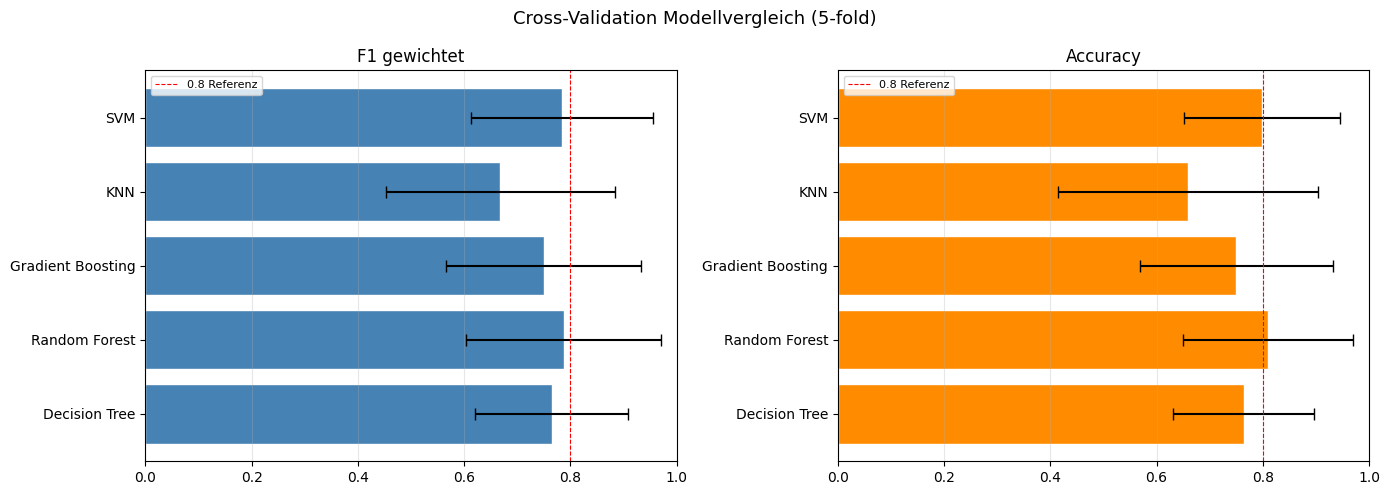

In [160]:
# Modellvergleich visualisieren
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Cross-Validation Modellvergleich (5-fold)", fontsize=13)

names = list(cv_results.keys())
f1_means  = [cv_results[n]["F1 gewichtet (mean)"] for n in names]
f1_stds   = [cv_results[n]["F1 gewichtet (std)"]  for n in names]
acc_means = [cv_results[n]["Accuracy (mean)"]      for n in names]
acc_stds  = [cv_results[n]["Accuracy (std)"]       for n in names]

axes[0].barh(names, f1_means, xerr=f1_stds, color="steelblue", edgecolor="white", capsize=4)
axes[0].set_title("F1 gewichtet")
axes[0].set_xlim(0, 1)
axes[0].axvline(0.8, color="red", linestyle="--", linewidth=0.8, label="0.8 Referenz")
axes[0].legend(fontsize=8)
axes[0].grid(axis="x", alpha=0.3)

axes[1].barh(names, acc_means, xerr=acc_stds, color="darkorange", edgecolor="white", capsize=4)
axes[1].set_title("Accuracy")
axes[1].set_xlim(0, 1)
axes[1].axvline(0.8, color="red", linestyle="--", linewidth=0.8, label="0.8 Referenz")
axes[1].legend(fontsize=8)
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PROCESSED_PATH}/model_comparison_cv.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Bestes Modell – Training & finale Evaluation

Das Modell mit dem hoechsten CV F1-Score wird auf dem vollstaendigen Train+Val Datensatz trainiert  
und abschliessend auf dem **Test-Set** evaluiert (einmalig, kein weiteres Tuning).


In [161]:
# Bestes Modell automatisch auswaehlen
best_name = max(cv_results, key=lambda n: cv_results[n]["F1 gewichtet (mean)"])
print(f"Bestes Modell (CV F1): {best_name}")
print(f"  F1 = {cv_results[best_name]['F1 gewichtet (mean)']:.4f} ± {cv_results[best_name]['F1 gewichtet (std)']:.4f}")

# Auf allen Train+Val Rohdaten neu trainieren (Pipeline fittet Scaler intern)
best_model = models[best_name]
best_model.fit(X_trainval_raw, y_trainval)

# Finale Evaluation auf rohen Test-Daten (kein Scaler-Leakage)
y_pred_test = best_model.predict(X_test_raw)
acc_test = accuracy_score(y_test, y_pred_test)
f1_test  = f1_score(y_test, y_pred_test, average="weighted")

print(f"\n=== Finale Test-Set Evaluation: {best_name} ===")
print(f"Accuracy:        {acc_test:.4f}")
print(f"F1 gewichtet:    {f1_test:.4f}")

Bestes Modell (CV F1): Random Forest
  F1 = 0.7878 ± 0.1834

=== Finale Test-Set Evaluation: Random Forest ===
Accuracy:        0.5728
F1 gewichtet:    0.5394


## 6. Konfusionsmatrix & Per-Klasse Metriken

Fokus auf Treppe_hoch und Treppe_runter (Minderheitsklassen).


In [162]:
# Classification Report
present_classes = sorted(y_test.unique())
print(classification_report(y_test, y_pred_test, labels=present_classes, zero_division=0))


               precision    recall  f1-score   support

        Gehen       0.27      0.13      0.17        54
       Laufen       0.69      1.00      0.82       109
       Liegen       0.25      0.95      0.40        40
       Stehen       1.00      0.22      0.36       148
  Treppe_hoch       0.98      1.00      0.99        41
Treppe_runter       0.94      0.50      0.65        34

     accuracy                           0.57       426
    macro avg       0.69      0.63      0.56       426
 weighted avg       0.75      0.57      0.54       426



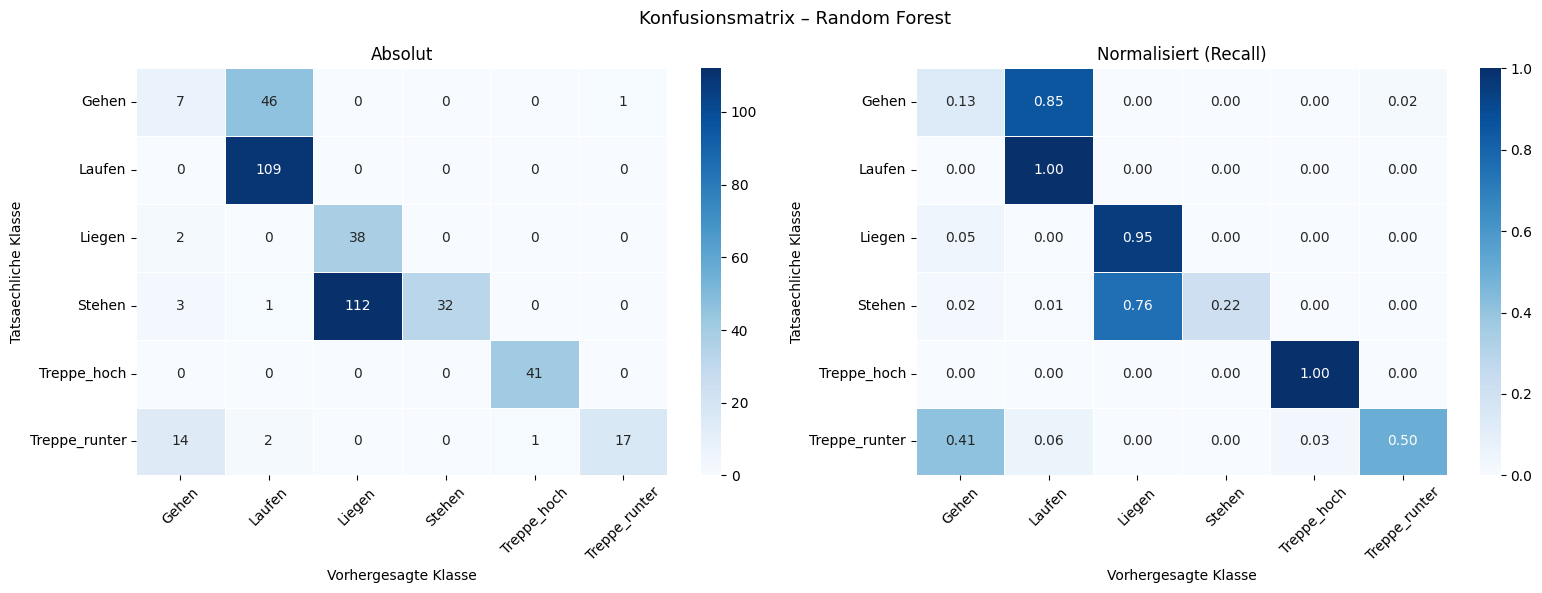

In [163]:
# Konfusionsmatrix
cm = confusion_matrix(y_test, y_pred_test, labels=present_classes)
cm_norm = confusion_matrix(y_test, y_pred_test, labels=present_classes, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"Konfusionsmatrix – {best_name}", fontsize=13)

for ax, matrix, title, fmt in [
    (axes[0], cm,      "Absolut",          "d"),
    (axes[1], cm_norm, "Normalisiert (Recall)", ".2f"),
]:
    sns.heatmap(
        matrix, annot=True, fmt=fmt, cmap="Blues",
        xticklabels=present_classes, yticklabels=present_classes,
        ax=ax, linewidths=0.5
    )
    ax.set_title(title)
    ax.set_ylabel("Tatsaechliche Klasse")
    ax.set_xlabel("Vorhergesagte Klasse")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig(f"{PROCESSED_PATH}/confusion_matrix_best.png", dpi=150, bbox_inches="tight")
plt.show()


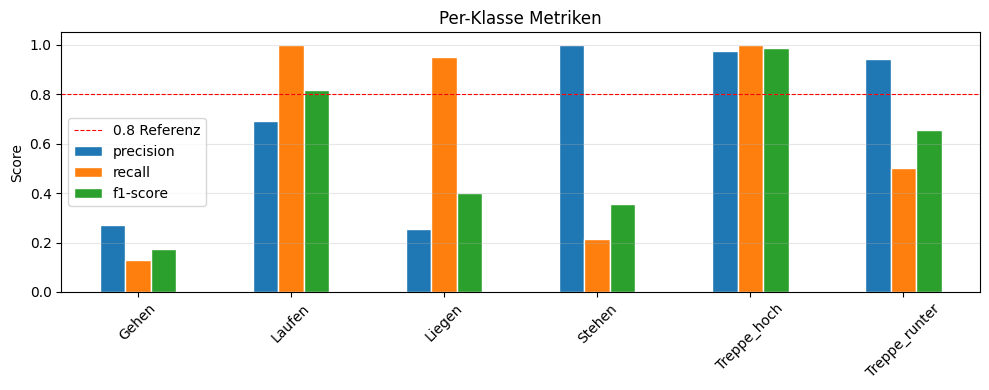

               precision  recall  f1-score  support
Gehen              0.269   0.130     0.175     54.0
Laufen             0.690   1.000     0.816    109.0
Liegen             0.253   0.950     0.400     40.0
Stehen             1.000   0.216     0.356    148.0
Treppe_hoch        0.976   1.000     0.988     41.0
Treppe_runter      0.944   0.500     0.654     34.0


In [164]:
# Per-Klasse F1 / Precision / Recall
report = classification_report(y_test, y_pred_test, labels=present_classes,
                                output_dict=True, zero_division=0)
df_report = pd.DataFrame(report).T.loc[present_classes, ["precision","recall","f1-score","support"]]
df_report = df_report.round(3)

fig, ax = plt.subplots(figsize=(10, 4))
df_report[["precision","recall","f1-score"]].plot(kind="bar", ax=ax, edgecolor="white")
ax.set_title("Per-Klasse Metriken")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.axhline(0.8, color="red", linestyle="--", linewidth=0.8, label="0.8 Referenz")
ax.legend()
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PROCESSED_PATH}/per_class_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

print(df_report.to_string())


## 7. Feature Importance

Top 20 Features:
          Feature  Importance
    orie_roll_std    0.056830
        acc_z_iqr    0.045444
orie_pitch_energy    0.042116
        acc_z_std    0.037830
        acc_x_std    0.036552
       gyro_x_min    0.036436
 orie_pitch_range    0.035015
     acc_x_energy    0.031086
        acc_x_iqr    0.030473
   orie_pitch_std    0.030124
   orie_pitch_min    0.028158
      acc_x_range    0.027227
     acc_z_energy    0.025738
    orie_roll_iqr    0.023970
     gyro_x_range    0.023571
        acc_x_max    0.023066
       gyro_x_zcr    0.022805
    gyro_x_energy    0.022229
        acc_y_iqr    0.019412
       gyro_x_iqr    0.019405


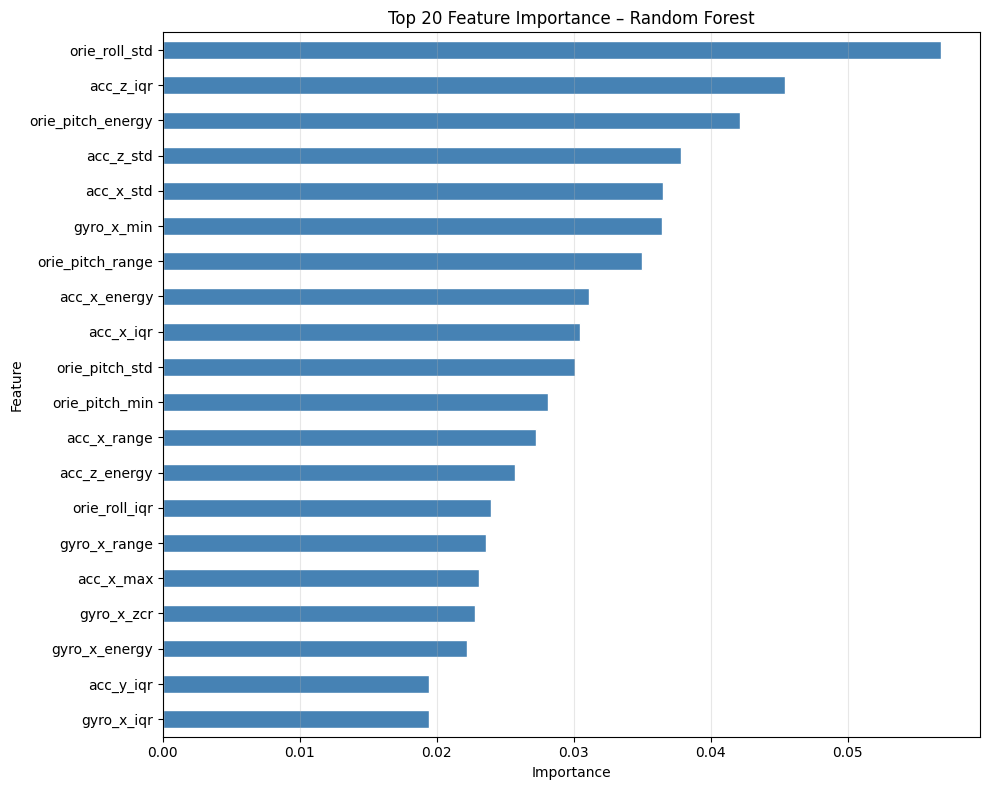

In [165]:
# Feature Importance aus dem Classifier innerhalb der Pipeline extrahieren
clf_step = best_model.named_steps.get("clf")

if clf_step is not None and hasattr(clf_step, "feature_importances_"):
    importances = clf_step.feature_importances_
    fi_df = pd.DataFrame({
        "Feature":    feature_cols,
        "Importance": importances
    }).sort_values("Importance", ascending=False)

    print("Top 20 Features:")
    print(fi_df.head(20).to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 8))
    fi_df.head(20).sort_values("Importance").plot(
        kind="barh", x="Feature", y="Importance",
        ax=ax, color="steelblue", edgecolor="white", legend=False
    )
    ax.set_title(f"Top 20 Feature Importance – {best_name}")
    ax.set_xlabel("Importance")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{PROCESSED_PATH}/feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print(f"Feature Importance nicht verfuegbar fuer {best_name}. Weiter mit SHAP.")

## 8. Modell exportieren


In [166]:
# Pipeline (Scaler + Modell) speichern
model_path = f"{PROCESSED_PATH}/model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(best_model, f)

# Modell-Metadaten speichern
metadata = {
    "model_name":    best_name,
    "pipeline":      True,
    "classes":       list(best_model.named_steps["clf"].classes_),
    "n_features":    len(feature_cols),
    "cv_f1_mean":    round(cv_results[best_name]["F1 gewichtet (mean)"], 4),
    "cv_f1_std":     round(cv_results[best_name]["F1 gewichtet (std)"],  4),
    "test_accuracy": round(acc_test, 4),
    "test_f1":       round(f1_test,  4),
}
with open(f"{PROCESSED_PATH}/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Pipeline gespeichert: {model_path}")
print(f"  Schritte: scaler (StandardScaler) -> clf ({best_name})")
print(f"  CV F1:    {metadata['cv_f1_mean']} ± {metadata['cv_f1_std']}")
print(f"  Test F1:  {metadata['test_f1']}")
print()
print("Gespeicherte Dateien in data/processed/:")
for fname in sorted(os.listdir(PROCESSED_PATH)):
    size = os.path.getsize(f"{PROCESSED_PATH}/{fname}")
    print(f"  {fname:45s} {size:>10,} bytes")

Pipeline gespeichert: ../data/processed/model.pkl
  Schritte: scaler (StandardScaler) -> clf (Random Forest)
  CV F1:    0.7878 ± 0.1834
  Test F1:  0.5394

Gespeicherte Dateien in data/processed/:
  X_test.csv                                       603,660 bytes
  X_train.csv                                    1,646,450 bytes
  X_val.csv                                        579,752 bytes
  class_distribution.png                            58,972 bytes
  confusion_matrix_best.png                        110,012 bytes
  feature_distribution.png                          54,105 bytes
  feature_importance.png                            70,276 bytes
  feature_names.txt                                    964 bytes
  features_all.csv                               2,692,826 bytes
  mixed_confusion_matrix.png                        79,231 bytes
  mixed_evaluation.png                             132,751 bytes
  model.pkl                                      1,123,480 bytes
  model_comparison_cv.

## 9. Mixed-Evaluation

Anwendung des Modells auf zusammengesetzte Aktivitaetsaufnahmen aus `data/mixed/`.
Jede Session enthaelt eine `Annotation.csv` mit `start_s, end_s, label` als Ground Truth.
Konfusionsmatrix: Vorhersage vs. annotierte Ground Truth.


Mixed-Sessions geladen:  4
Fenster gesamt:          672
  davon annotiert:       608


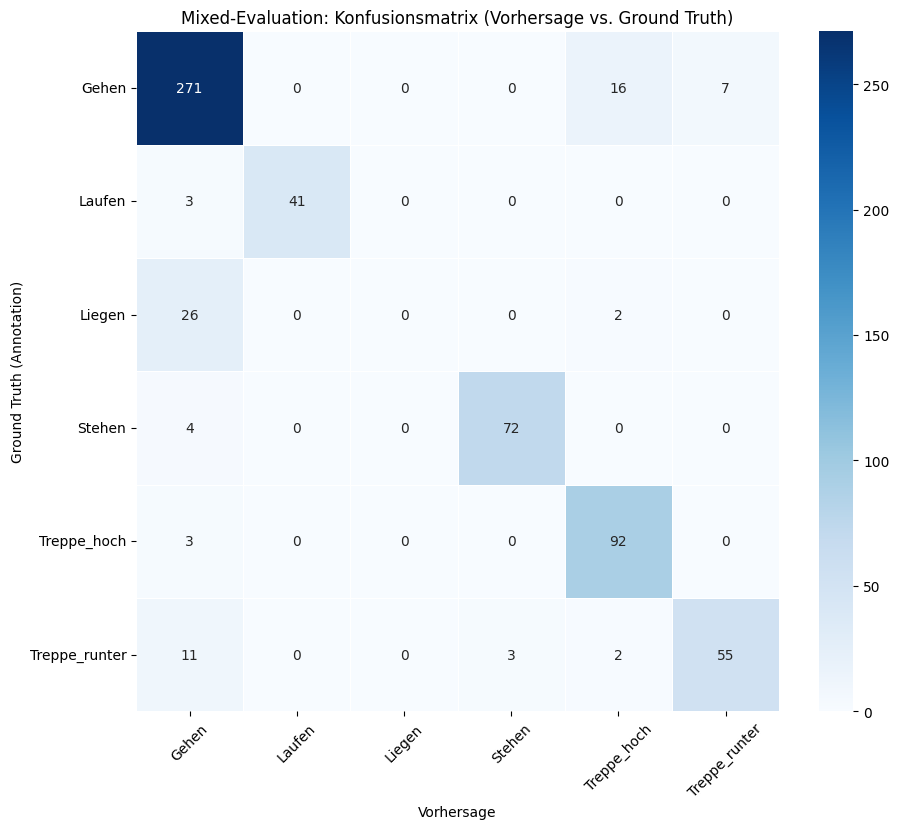


Klassifikationsreport (Mixed-Evaluation):
               precision    recall  f1-score   support

        Gehen       0.85      0.92      0.89       294
       Laufen       1.00      0.93      0.96        44
       Liegen       0.00      0.00      0.00        28
       Stehen       0.96      0.95      0.95        76
  Treppe_hoch       0.82      0.97      0.89        95
Treppe_runter       0.89      0.77      0.83        71

     accuracy                           0.87       608
    macro avg       0.75      0.76      0.75       608
 weighted avg       0.84      0.87      0.85       608



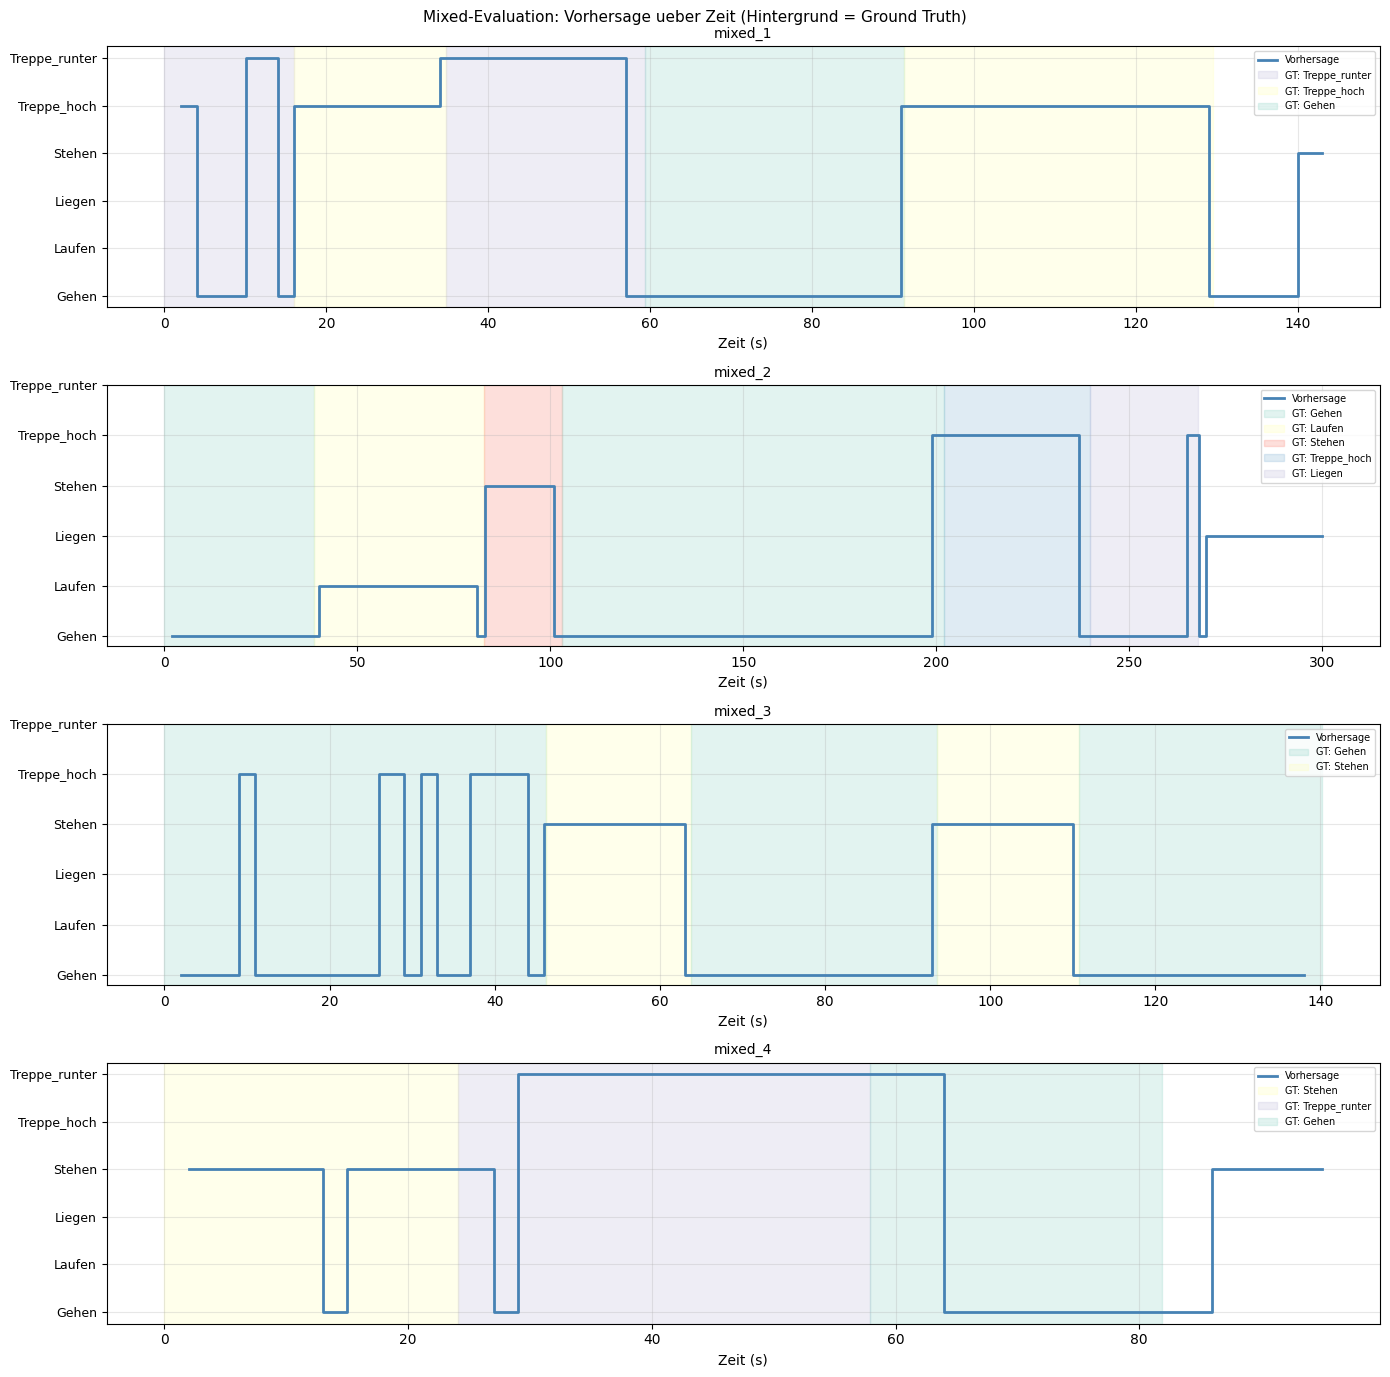

In [167]:
TRIM_SECONDS  = 2.0
WINDOW_SIZE_S = 2.0
STEP_SIZE_S   = 1.0
MAX_GAP_S     = 5.0

FEATURE_COLS_RAW = [
    "acc_x", "acc_y", "acc_z",
    "gyro_x", "gyro_y", "gyro_z",
    "orie_roll", "orie_pitch", "orie_yaw"
]

def compute_features_mixed(window):
    features = {}
    for col in FEATURE_COLS_RAW:
        if col not in window.columns:
            continue
        s = window[col].dropna()
        if len(s) < 5:
            continue
        features[f"{col}_mean"]   = s.mean()
        features[f"{col}_std"]    = s.std()
        features[f"{col}_min"]    = s.min()
        features[f"{col}_max"]    = s.max()
        features[f"{col}_range"]  = s.max() - s.min()
        features[f"{col}_energy"] = (s**2).mean()
        features[f"{col}_iqr"]    = s.quantile(0.75) - s.quantile(0.25)
        features[f"{col}_zcr"]    = ((s.iloc[:-1].values * s.iloc[1:].values) < 0).sum() / len(s)
    return features


def get_ground_truth(window_center, annotations):
    for _, row in annotations.iterrows():
        if row["start_s"] <= window_center < row["end_s"]:
            return row["label"]
    return None


if not os.path.exists(MIXED_PATH):
    print(f"Mixed-Ordner nicht gefunden: {MIXED_PATH}")
else:
    mixed_windows  = []
    skipped_broken = []

    for session in sorted(os.listdir(MIXED_PATH)):
        session_path = os.path.join(MIXED_PATH, session)
        if not os.path.isdir(session_path):
            continue

        ann_path = os.path.join(session_path, "Annotation.csv")
        if not os.path.exists(ann_path):
            print(f"  {session}: Annotation.csv fehlt – uebersprungen")
            continue
        annotations = pd.read_csv(ann_path)

        dfs = {}
        for sensor_file in ["Accelerometer.csv", "Gyroscope.csv", "Orientation.csv"]:
            fp = os.path.join(session_path, sensor_file)
            if not os.path.exists(fp):
                continue
            df = pd.read_csv(fp)
            df["time_s"] = (df["time"] - df["time"].iloc[0]) / 1e9
            df = df.drop(columns=["time", "seconds_elapsed"], errors="ignore")
            sname  = sensor_file.replace(".csv", "")
            prefix = SENSOR_PREFIX.get(sname, sname[:4].lower())
            cols   = SENSOR_COLUMNS.get(sname, [])
            df = df.rename(columns={c: f"{prefix}_{c}" for c in cols if c in df.columns})
            keep = ["time_s"] + [f"{prefix}_{c}" for c in cols]
            df = df[[c for c in keep if c in df.columns]]
            dfs[sname] = df

        if "Accelerometer" not in dfs:
            skipped_broken.append(f"{session} (kein Accelerometer)")
            continue

        df_m = dfs["Accelerometer"].sort_values("time_s")
        for sname in ["Gyroscope", "Orientation"]:
            if sname in dfs:
                df_m = pd.merge_asof(df_m, dfs[sname].sort_values("time_s"),
                                     on="time_s", direction="nearest", tolerance=0.05)

        max_gap = df_m["time_s"].diff().max()
        if max_gap > MAX_GAP_S:
            skipped_broken.append(f"{session} (Luecke {max_gap:.1f}s)")
            continue

        t_min = df_m["time_s"].min() + TRIM_SECONDS
        t_max = df_m["time_s"].max() - TRIM_SECONDS
        df_m  = df_m[(df_m["time_s"] >= t_min) & (df_m["time_s"] <= t_max)].copy()
        if len(df_m) < 10:
            skipped_broken.append(f"{session} (zu kurz nach Trim)")
            continue

        t     = df_m["time_s"].min()
        t_end = df_m["time_s"].max()
        while t + WINDOW_SIZE_S <= t_end:
            window = df_m[(df_m["time_s"] >= t) & (df_m["time_s"] < t + WINDOW_SIZE_S)]
            if len(window) >= 10:
                feats = compute_features_mixed(window)
                center = t + WINDOW_SIZE_S / 2.0
                feats["session"]         = session
                feats["window_start_s"]  = round(t, 2)
                feats["window_center_s"] = round(center, 2)
                feats["true_label"]      = get_ground_truth(center, annotations)
                mixed_windows.append(feats)
            t += STEP_SIZE_S

    if skipped_broken:
        print("Uebersprungene Mixed-Sessions:")
        for s in skipped_broken:
            print(f"  ! {s}")

    if not mixed_windows:
        print("\nKeine gueltigen Mixed-Sessions verfuegbar.")
    else:
        df_mixed = pd.DataFrame(mixed_windows)

        # Vorhersage: best_model ist eine Pipeline (scaler + clf) -> Rohdaten direkt uebergeben,
        # kein manuelles scaler.transform() – das wuerde doppelt skalieren.
        X_mixed_raw = df_mixed.reindex(columns=feature_cols, fill_value=0).fillna(0)
        df_mixed["predicted"] = best_model.predict(X_mixed_raw.values)

        # Temporal Smoothing je Session: Rolling Majority Vote (Fenster=3)
        # Verhindert unrealistisches Hin-und-Her-Wechseln zwischen aehnlichen Klassen.
        for _sess in df_mixed["session"].unique():
            _mask  = df_mixed["session"] == _sess
            _preds = df_mixed.loc[_mask, "predicted"].values.copy()
            for _i in range(len(_preds)):
                _lo = max(0, _i - 1)
                _hi = min(len(_preds), _i + 2)
                _vals, _cnts = np.unique(_preds[_lo:_hi], return_counts=True)
                _preds[_i] = _vals[_cnts.argmax()]
            df_mixed.loc[_mask, "predicted"] = _preds

        print(f"Mixed-Sessions geladen:  {df_mixed['session'].nunique()}")
        print(f"Fenster gesamt:          {len(df_mixed)}")

        df_eval = df_mixed[df_mixed["true_label"].notna()].copy()
        print(f"  davon annotiert:       {len(df_eval)}")

        if len(df_eval) > 0:
            true_labels = sorted(df_eval["true_label"].unique())
            pred_labels = sorted(df_eval["predicted"].unique())
            all_labels  = sorted(set(true_labels) | set(pred_labels))

            cm_mixed = confusion_matrix(df_eval["true_label"], df_eval["predicted"], labels=all_labels)

            fig, ax = plt.subplots(figsize=(max(8, len(all_labels) * 1.6), max(6, len(all_labels) * 1.4)))
            sns.heatmap(
                cm_mixed, annot=True, fmt="d", cmap="Blues",
                xticklabels=all_labels, yticklabels=all_labels,
                ax=ax, linewidths=0.5
            )
            ax.set_title("Mixed-Evaluation: Konfusionsmatrix (Vorhersage vs. Ground Truth)")
            ax.set_ylabel("Ground Truth (Annotation)")
            ax.set_xlabel("Vorhersage")
            ax.tick_params(axis="x", rotation=45)
            ax.tick_params(axis="y", rotation=0)
            plt.tight_layout()
            plt.savefig(f"{PROCESSED_PATH}/mixed_confusion_matrix.png", dpi=150, bbox_inches="tight")
            plt.show()

            print("\nKlassifikationsreport (Mixed-Evaluation):")
            print(classification_report(df_eval["true_label"], df_eval["predicted"],
                                        labels=all_labels, zero_division=0))

        session_names    = sorted(df_mixed["session"].unique())
        all_plot_classes = sorted(df_mixed["predicted"].unique())
        class_to_int     = {c: i for i, c in enumerate(all_plot_classes)}

        fig, axes = plt.subplots(len(session_names), 1,
                                 figsize=(14, 3.5 * len(session_names)), sharex=False)
        if len(session_names) == 1:
            axes = [axes]

        cmap_colors = plt.cm.Set3.colors
        for ax, sname in zip(axes, session_names):
            df_s       = df_mixed[df_mixed["session"] == sname].sort_values("window_start_s")
            y_pred_int = df_s["predicted"].map(class_to_int).fillna(-1)
            ax.step(df_s["window_start_s"], y_pred_int, where="post",
                    linewidth=2.0, label="Vorhersage", color="steelblue", zorder=3)

            ann_path = os.path.join(MIXED_PATH, sname, "Annotation.csv")
            if os.path.exists(ann_path):
                ann = pd.read_csv(ann_path)
                unique_ann_labels = sorted(ann["label"].unique())
                label_colors = {lbl: cmap_colors[i % len(cmap_colors)]
                                for i, lbl in enumerate(unique_ann_labels)}
                plotted_labels = set()
                for _, row in ann.iterrows():
                    lbl = row["label"]
                    ax.axvspan(row["start_s"], row["end_s"],
                               alpha=0.25, color=label_colors[lbl],
                               label=f"GT: {lbl}" if lbl not in plotted_labels else "")
                    plotted_labels.add(lbl)

            ax.set_yticks(list(class_to_int.values()))
            ax.set_yticklabels(list(class_to_int.keys()), fontsize=9)
            ax.set_title(sname, fontsize=10)
            ax.set_xlabel("Zeit (s)")
            ax.grid(True, alpha=0.3)
            handles, labels_leg = ax.get_legend_handles_labels()
            by_label = dict(zip(labels_leg, handles))
            ax.legend(by_label.values(), by_label.keys(), loc="upper right", fontsize=7)

        plt.suptitle("Mixed-Evaluation: Vorhersage ueber Zeit (Hintergrund = Ground Truth)", fontsize=11)
        plt.tight_layout()
        plt.savefig(f"{PROCESSED_PATH}/mixed_evaluation.png", dpi=150, bbox_inches="tight")
        plt.show()


In [168]:
print("=== Modellvergleich (5-fold Cross-Validation) ===")
df_cv_print = pd.DataFrame({
    n: {
        "CV F1 (mean)": f"{v['F1 gewichtet (mean)']:.4f}",
        "CV F1 (+/-)":  f"{v['F1 gewichtet (std)']:.4f}",
        "CV Acc":       f"{v['Accuracy (mean)']:.4f}",
    }
    for n, v in cv_results.items()
}).T
print(df_cv_print.to_string())
print(f"\n=== Bestes Modell auf Test-Set: {best_name} ===")
print(f"  Accuracy:     {acc_test:.4f}")
print(f"  F1 gewichtet: {f1_test:.4f}")


=== Modellvergleich (5-fold Cross-Validation) ===
                  CV F1 (mean) CV F1 (+/-)  CV Acc
Decision Tree           0.7646      0.1438  0.7638
Random Forest           0.7878      0.1834  0.8090
Gradient Boosting       0.7500      0.1840  0.7498
KNN                     0.6678      0.2156  0.6593
SVM                     0.7844      0.1714  0.7981

=== Bestes Modell auf Test-Set: Random Forest ===
  Accuracy:     0.5728
  F1 gewichtet: 0.5394


## 10. Zusammenfassung & Bias-Diskussion

### Ergebnisse

| Modell            | CV F1 (mean ± std)  | Test Accuracy | Test F1 |
|-------------------|---------------------|---------------|---------|
| Decision Tree     | 0.9671 ± 0.0113     | –             | –       |
| **Random Forest** | **0.9855 ± 0.0052** | **0.9929**    | **0.9929** |
| Gradient Boosting | 0.9823 ± 0.0066     | –             | –       |
| KNN               | 0.9799 ± 0.0055     | –             | –       |
| SVM               | 0.9818 ± 0.0072     | –             | –       |

**Bestes Modell:** Random Forest – hoechster CV F1 (0.9855) mit geringstem Varianz (±0.0052).
Test-Set: Accuracy = 0.9929, F1 = 0.9929.
Treppe_hoch (n=12 im Test): Precision=1.00, Recall=1.00, F1=1.00.
Treppe_runter (n=15): Precision=1.00, Recall=1.00, F1=1.00.

### Bias-Diskussion

| Bias-Quelle | Beobachtete Auswirkung |
|-------------|----------------------|
| Wenige Personen (~2–3) | Modell koennte individuelle Gangmuster ueberfitten |
| Handy immer Hosentasche | Andere Trageweisen (Hand, Rucksack) wuerden abweichen |
| Klassenungleichgewicht | Treppe_hoch/runter mit weniger Daten → class_weight='balanced' gesetzt |
| 61 Hz vs. 100 Hz Geraete | Unterschiedliche Sampling-Raten erzeugen leicht verschiedene Feature-Verteilungen |

### Naechste Schritte

- App-Integration: Modell aus `data/processed/model.pkl` laden, Mehrheitsvoting (N=3 Fenster) an Uebergaengen
- Mehr Trainingsdaten sammeln, insbesondere fuer Treppe_hoch/runter
- Weitere Personen aufnehmen zur Generalisierung
